# 02. 공식 Baseline 재현 분석

    > 작성일: 2026-07-06 KST  
    > 목적: 공식 `baseline.ipynb`의 데이터 로드, feature 생성, RandomForest 학습 구조를 재현하고 2024 holdout으로 local score 기준선을 만든다.

    이 노트북은 데이터분석 산출물이다. 제출 CSV, 모델 파일, output 산출물은 생성하지 않는다. 공식 baseline을 그대로 복사해 제출하는 것이 아니라, 이후 `train.py`/`inference.py` 분리 구현으로 옮기기 전에 데이터 구조와 의사결정을 잠그는 목적이다.

## Decision Box 0: 이번 노트북의 경계

    | 항목 | 결정 | 이유 |
    |---|---|---|
    | 분석 형식 | `.ipynb` | 데이터분석 과정은 노트북으로 남긴다는 운영 원칙을 따른다. |
    | 모델 | 공식 RandomForest baseline만 사용 | LightGBM/CatBoost 등 개선 모델은 아직 시작하지 않는다. |
    | 외부 데이터 | 사용하지 않음 | 공식 baseline 재현 단계이므로 공식 배포 데이터만 사용한다. |
    | SCADA feature | 사용하지 않음 | 공식 baseline은 LDAPS/GFS 격자 평균과 calendar feature만 사용한다. |
    | 제출 파일 | 저장하지 않음 | 이번 작업은 제출이 아니라 local 기준선과 재현 설계 잠금이다. |
    | 검증 | 2024 time holdout | random split을 피하고 2025 평가 상황과 가까운 1년 holdout으로 본다. |

In [1]:
from pathlib import Path
import json
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
  PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
  sys.path.insert(0, str(SRC_DIR))

from baram.metrics import CAPACITY_KWH, TARGET_COLS, metric

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "open"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

sns.set_theme(style="whitegrid")
font_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "DejaVu Sans"]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
selected_font = next((font for font in font_candidates if font in available_fonts), "DejaVu Sans")
plt.rcParams["font.family"] = selected_font
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

print("프로젝트 루트:", PROJECT_ROOT)
print("선택된 한글 표시 폰트:", selected_font)
print("데이터 폴더 존재:", DATA_DIR.exists())
print("대상 컬럼:", TARGET_COLS)
print("capacity kWh:", CAPACITY_KWH)

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

OFFICIAL_BASELINE_NOTEBOOK = PROJECT_ROOT / "references" / "official" / "notebooks" / "baseline.ipynb"
RANDOM_STATE = 42
OFFICIAL_RF_PARAMS = {
  "n_estimators": 120,
  "max_depth": 14,
  "min_samples_leaf": 8,
  "max_features": "sqrt",
  "random_state": RANDOM_STATE,
  "n_jobs": -1,
}

프로젝트 루트: C:\Users\kik32\workspace\Dacon\2026-BARAM-Wind-Power-Prediction-AI-Competition
선택된 한글 표시 폰트: Malgun Gothic
데이터 폴더 존재: True
대상 컬럼: ['kpx_group_1', 'kpx_group_2', 'kpx_group_3']
capacity kWh: {'kpx_group_1': 21600, 'kpx_group_2': 21600, 'kpx_group_3': 21000}


## 1. 공식 baseline 코드 구조 확인

    공식 baseline은 다음 순서다.

    1. `train_labels`, `sample_submission`, LDAPS/GFS train/test CSV 로드
    2. LDAPS/GFS를 `forecast_kst_dtm` 기준으로 격자 평균 집계
    3. calendar feature 생성
    4. `SimpleImputer(strategy="median")` 적용
    5. target별 non-null label 행만 사용해 `RandomForestRegressor` 개별 학습
    6. test 예측 후 `0 ~ capacity` clipping
    7. `baseline_submit.csv` 저장

    이번 노트북에서는 7번 저장은 하지 않고, 2024 holdout을 추가해 local score를 계산한다.

In [2]:
official_notebook = json.loads(OFFICIAL_BASELINE_NOTEBOOK.read_text(encoding="utf-8"))
code_cells = ["".join(cell.get("source", [])) for cell in official_notebook["cells"] if cell.get("cell_type") == "code"]
pd.DataFrame(
  {
    "code_cell": list(range(len(code_cells))),
    "line_count": [len(cell.splitlines()) for cell in code_cells],
    "first_line": [cell.splitlines()[0] if cell.splitlines() else "" for cell in code_cells],
  }
)

,code_cell,line_count,first_line
0,0,6,from pathlib import Path
1,1,26,"DATA_DIR = Path(""."")"
2,2,49,"def aggregate_weather(df, prefix):"
3,3,25,"imputer = SimpleImputer(strategy=""median"")"
4,4,8,"submission = sample_submission[[""forecast_id"",..."
5,5,3,"output_path = DATA_DIR / ""baseline_submit.csv"""


## 2. 데이터 로드와 schema audit

    원본 CSV/XLSX는 Git에 올리지 않고 `data/raw/open/`에 로컬로만 둔다. 이 노트북은 파일 존재와 shape만 확인하고, 원본 파일을 수정하지 않는다.

In [3]:
required_files = [
  TRAIN_DIR / "train_labels.csv",
  DATA_DIR / "sample_submission.csv",
  TRAIN_DIR / "ldaps_train.csv",
  TRAIN_DIR / "gfs_train.csv",
  TEST_DIR / "ldaps_test.csv",
  TEST_DIR / "gfs_test.csv",
]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
  raise FileNotFoundError("필수 공식 데이터 파일이 없습니다: " + ", ".join(str(path) for path in missing_files))

train_labels = pd.read_csv(TRAIN_DIR / "train_labels.csv", encoding="utf-8-sig")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv", encoding="utf-8-sig")
ldaps_train = pd.read_csv(TRAIN_DIR / "ldaps_train.csv", encoding="utf-8-sig")
gfs_train = pd.read_csv(TRAIN_DIR / "gfs_train.csv", encoding="utf-8-sig")
ldaps_test = pd.read_csv(TEST_DIR / "ldaps_test.csv", encoding="utf-8-sig")
gfs_test = pd.read_csv(TEST_DIR / "gfs_test.csv", encoding="utf-8-sig")

train_labels["kst_dtm"] = pd.to_datetime(train_labels["kst_dtm"])
sample_submission["forecast_kst_dtm"] = pd.to_datetime(sample_submission["forecast_kst_dtm"])

inventory = pd.DataFrame(
  [
    ("train_labels", train_labels.shape[0], train_labels.shape[1], str(train_labels["kst_dtm"].min()), str(train_labels["kst_dtm"].max())),
    ("sample_submission", sample_submission.shape[0], sample_submission.shape[1], str(sample_submission["forecast_kst_dtm"].min()), str(sample_submission["forecast_kst_dtm"].max())),
    ("ldaps_train", ldaps_train.shape[0], ldaps_train.shape[1], "", ""),
    ("gfs_train", gfs_train.shape[0], gfs_train.shape[1], "", ""),
    ("ldaps_test", ldaps_test.shape[0], ldaps_test.shape[1], "", ""),
    ("gfs_test", gfs_test.shape[0], gfs_test.shape[1], "", ""),
  ],
  columns=["file", "rows", "cols", "start", "end"],
)
inventory

,file,rows,cols,start,end
0,train_labels,26304,4,2022-01-01 01:00:00,2025-01-01 00:00:00
1,sample_submission,8760,5,2025-01-01 01:00:00,2026-01-01 00:00:00
2,ldaps_train,420864,35,,
3,gfs_train,236736,40,,
4,ldaps_test,140160,35,,
5,gfs_test,78840,40,,


In [4]:
label_audit_rows = []
for target in TARGET_COLS:
  capacity = CAPACITY_KWH[target]
  series = train_labels[target]
  label_audit_rows.append(
    {
      "target": target,
      "capacity": capacity,
      "non_null": int(series.notna().sum()),
      "missing": int(series.isna().sum()),
      "min": float(series.min(skipna=True)),
      "max": float(series.max(skipna=True)),
      "capacity_exceed": int((series > capacity).sum()),
      "official_valid_candidate": int((series >= capacity * 0.10).sum()),
    }
  )
pd.DataFrame(label_audit_rows)

,target,capacity,non_null,missing,min,max,capacity_exceed,official_valid_candidate
0,kpx_group_1,21600,26200,104,0.0,21275.305,0,15915
1,kpx_group_2,21600,26201,103,0.0,21362.084,0,15891
2,kpx_group_3,21000,17538,8766,0.0,21130.674,38,9414


## 3. 공식 feature 생성 함수 재현

    아래 함수는 공식 baseline의 `aggregate_weather`, `calendar_features` 구조를 유지한다. 개선 피처는 아직 넣지 않는다.

In [5]:
def aggregate_weather(df, prefix):
  frame = df.copy()
  frame["forecast_kst_dtm"] = pd.to_datetime(frame["forecast_kst_dtm"])
  drop_cols = {"data_available_kst_dtm", "grid_id", "latitude", "longitude"}
  value_cols = [col for col in frame.columns if col not in {"forecast_kst_dtm", *drop_cols}]
  aggregated = frame.groupby("forecast_kst_dtm")[value_cols].mean()
  aggregated.columns = [f"{prefix}_{col}_mean" for col in aggregated.columns]
  return aggregated.reset_index()


def calendar_features(dt_series):
  dt = pd.to_datetime(dt_series)
  out = pd.DataFrame(index=dt.index)
  out["month"] = dt.dt.month
  out["day"] = dt.dt.day
  out["hour"] = dt.dt.hour
  out["dayofweek"] = dt.dt.dayofweek
  out["is_weekend"] = dt.dt.dayofweek.isin([5, 6]).astype(int)
  out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
  out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
  out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
  out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
  return out


def build_feature_frame(label_df, ldaps_df, gfs_df, sample_df=None):
  weather = aggregate_weather(ldaps_df, "ldaps").merge(
    aggregate_weather(gfs_df, "gfs"), on="forecast_kst_dtm", how="inner"
  )
  if label_df is not None:
    base = label_df.rename(columns={"kst_dtm": "forecast_kst_dtm"})
    merged = base.merge(weather, on="forecast_kst_dtm", how="left")
    X = pd.concat(
      [calendar_features(merged["forecast_kst_dtm"]), merged.drop(columns=["forecast_kst_dtm", *TARGET_COLS])],
      axis=1,
    )
    return merged, X, weather

  merged = sample_df[["forecast_id", "forecast_kst_dtm"]].merge(weather, on="forecast_kst_dtm", how="left")
  X = pd.concat(
    [calendar_features(merged["forecast_kst_dtm"]), merged.drop(columns=["forecast_id", "forecast_kst_dtm"])],
    axis=1,
  )
  return merged, X, weather


train_df, X_train, train_weather = build_feature_frame(train_labels, ldaps_train, gfs_train)
test_df, X_test, test_weather = build_feature_frame(None, ldaps_test, gfs_test, sample_submission)

pd.DataFrame(
  [
    ("train_weather", train_weather.shape[0], train_weather.shape[1], int(train_weather.isna().sum().sum())),
    ("test_weather", test_weather.shape[0], test_weather.shape[1], int(test_weather.isna().sum().sum())),
    ("train_df", train_df.shape[0], train_df.shape[1], int(train_df.isna().sum().sum())),
    ("test_df", test_df.shape[0], test_df.shape[1], int(test_df.isna().sum().sum())),
    ("X_train", X_train.shape[0], X_train.shape[1], int(X_train.isna().sum().sum())),
    ("X_test", X_test.shape[0], X_test.shape[1], int(X_test.isna().sum().sum())),
  ],
  columns=["name", "rows", "cols", "missing_cells"],
)

,name,rows,cols,missing_cells
0,train_weather,26304,66,0
1,test_weather,8760,66,47
2,train_df,26304,69,8973
3,test_df,8760,67,47
4,X_train,26304,74,0
5,X_test,8760,74,47


## 4. 2024 holdout local score

    공식 baseline 노트북에는 validation이 없다. 여기서는 같은 feature와 같은 RandomForest 파라미터를 쓰되, 2022~2023을 학습하고 2024를 검증한다. Group 3은 2022 label이 없으므로 target별 non-null mask가 자동으로 2023 중심 학습을 만든다.

In [6]:
def train_and_predict_by_target(X_train_local, train_local_df, X_predict_local, model_params):
  imputer = SimpleImputer(strategy="median")
  X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_local), columns=X_train_local.columns, index=X_train_local.index)
  X_predict_imp = pd.DataFrame(imputer.transform(X_predict_local), columns=X_predict_local.columns, index=X_predict_local.index)

  predictions = pd.DataFrame(index=X_predict_local.index)
  train_rows = {}

  for target in TARGET_COLS:
    train_mask = train_local_df[target].notna()
    y_train = train_local_df.loc[train_mask, target]
    model = RandomForestRegressor(**model_params)
    model.fit(X_train_imp.loc[train_mask], y_train)
    pred = model.predict(X_predict_imp)
    predictions[target] = np.clip(pred, 0, CAPACITY_KWH[target])
    train_rows[target] = int(train_mask.sum())

  return predictions, train_rows


train_years = train_df["forecast_kst_dtm"].dt.year
local_train_mask = train_years < 2024
local_valid_mask = train_years == 2024

X_local_train = X_train.loc[local_train_mask].copy()
train_local_df = train_df.loc[local_train_mask].copy()
X_local_valid = X_train.loc[local_valid_mask].copy()
valid_df = train_df.loc[local_valid_mask, ["forecast_kst_dtm", *TARGET_COLS]].copy()

valid_pred, train_rows = train_and_predict_by_target(
  X_local_train, train_local_df, X_local_valid, OFFICIAL_RF_PARAMS
)

score_tuple = metric(valid_df[TARGET_COLS], valid_pred[TARGET_COLS])
pd.DataFrame(
  [
    ("total_score", score_tuple[0]),
    ("one_minus_nmae", score_tuple[1]),
    ("ficr", score_tuple[2]),
  ],
  columns=["metric", "value"],
)

,metric,value
0,total_score,0.576938
1,one_minus_nmae,0.863228
2,ficr,0.290647


In [7]:
diagnostic_rows = []
for target in TARGET_COLS:
  capacity = CAPACITY_KWH[target]
  actual = valid_df[target]
  pred = valid_pred[target]
  valid_mask = actual >= capacity * 0.10
  error_rate = (pred[valid_mask] - actual[valid_mask]).abs() / capacity
  diagnostic_rows.append(
    {
      "target": target,
      "train_rows": train_rows[target],
      "valid_rows": int(actual.notna().sum()),
      "official_valid_rows": int(valid_mask.sum()),
      "mae_all": float((pred[actual.notna()] - actual[actual.notna()]).abs().mean()),
      "nmae_valid": float(error_rate.mean()),
      "within_6pct": float((error_rate <= 0.06).mean()),
      "within_8pct": float((error_rate <= 0.08).mean()),
      "pred_min": float(pred.min()),
      "pred_max": float(pred.max()),
    }
  )

diagnostic_df = pd.DataFrame(diagnostic_rows)
diagnostic_df

,target,train_rows,valid_rows,official_valid_rows,mae_all,nmae_valid,within_6pct,within_8pct,pred_min,pred_max
0,kpx_group_1,17421,8778,4989,2215.631078,0.129808,0.283223,0.377430,224.646139,18894.488671
1,kpx_group_2,17422,8778,4976,2188.699786,0.128420,0.306069,0.401929,263.016646,19391.718817
2,kpx_group_3,8759,8778,4566,2175.441546,0.152087,0.260841,0.345817,164.088409,17407.855592


## 5. baseline 진단 시각화

    공식 baseline은 제출 smoke test로는 유용하지만 validation과 진단 시각화가 없다. 아래 그래프는 다음 리팩토링에서 scoreboard로 옮겨야 할 최소 진단이다.

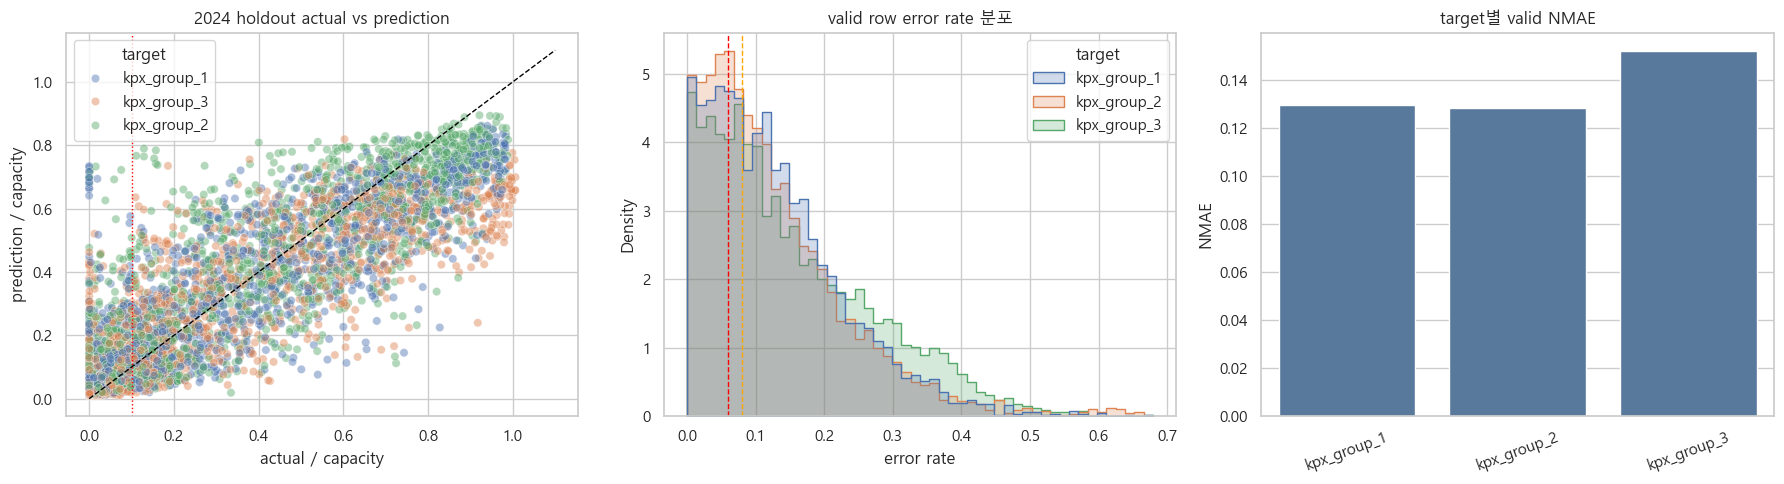

In [8]:
plot_rows = []
for target in TARGET_COLS:
  capacity = CAPACITY_KWH[target]
  actual = valid_df[target]
  pred = valid_pred[target]
  valid_mask = actual >= capacity * 0.10
  frame = pd.DataFrame(
    {
      "target": target,
      "actual_rate": actual / capacity,
      "pred_rate": pred / capacity,
      "error_rate": (pred - actual).abs() / capacity,
      "official_valid": valid_mask,
      "forecast_kst_dtm": valid_df["forecast_kst_dtm"],
    }
  )
  plot_rows.append(frame)
plot_df = pd.concat(plot_rows, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=plot_df.sample(min(6000, len(plot_df)), random_state=42), x="actual_rate", y="pred_rate", hue="target", alpha=0.45, ax=axes[0])
axes[0].plot([0, 1.1], [0, 1.1], color="black", linestyle="--", linewidth=1)
axes[0].axvline(0.10, color="red", linestyle=":", linewidth=1)
axes[0].set_title("2024 holdout actual vs prediction")
axes[0].set_xlabel("actual / capacity")
axes[0].set_ylabel("prediction / capacity")

sns.histplot(data=plot_df[plot_df["official_valid"]], x="error_rate", hue="target", bins=50, element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].axvline(0.06, color="red", linestyle="--", linewidth=1)
axes[1].axvline(0.08, color="orange", linestyle="--", linewidth=1)
axes[1].set_title("valid row error rate 분포")
axes[1].set_xlabel("error rate")

sns.barplot(data=diagnostic_df, x="target", y="nmae_valid", ax=axes[2], color="#4C78A8")
axes[2].set_title("target별 valid NMAE")
axes[2].set_xlabel("")
axes[2].set_ylabel("NMAE")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Decision Box 1: baseline 재현에서 확인한 한계

    | 관찰 | 해석 | 다음 작업 반영 |
    |---|---|---|
    | 공식 baseline은 validation이 없다 | LB 제출 전 local score 기준선이 비어 있다 | train/inference 분리 전에 validation scoreboard를 먼저 둔다 |
    | feature가 격자 평균뿐이다 | 공간 분산, lead hour, 모델 간 차이를 버린다 | P0 개선은 `mean/std/min/max`와 lead hour부터 검토한다 |
    | target별 모델은 유지 가치가 있다 | Group 3 label 결측 구조를 자연스럽게 처리한다 | Group 3 전용 fold와 pooled model을 나중에 비교한다 |
    | clipping은 metric 내부가 아니라 inference 후처리다 | official metric과 후처리 책임을 분리해야 한다 | validator/후처리 모듈에서 음수와 capacity 초과를 다룬다 |

## 6. 제출 형식 preview

    아래 셀은 sample submission 컬럼과 inference feature shape만 확인한다. 이번 노트북에서는 `baseline_submit.csv`를 저장하지 않는다.

In [9]:
submission_schema = pd.DataFrame(
  {
    "column": sample_submission.columns,
    "dtype": [str(sample_submission[col].dtype) for col in sample_submission.columns],
    "missing": [int(sample_submission[col].isna().sum()) for col in sample_submission.columns],
  }
)

print("sample_submission rows:", len(sample_submission))
print("X_test shape:", X_test.shape)
submission_schema

sample_submission rows: 8760
X_test shape: (8760, 74)


,column,dtype,missing
0,forecast_id,str,0
1,forecast_kst_dtm,datetime64[us],0
2,kpx_group_1,int64,0
3,kpx_group_2,int64,0
4,kpx_group_3,int64,0


## 최종 결정 로그

    | 날짜 | 결정 | 이유 |
    |---|---|---|
    | 2026-07-06 | baseline 재현 분석은 `.ipynb`로 남김 | 데이터분석 과정은 노트북으로 축적한다는 운영 원칙을 반영 |
    | 2026-07-06 | 공식 baseline feature/model 구조를 우선 고정 | 개선 모델 이전에 공식 기준선을 재현해야 local/LB 괴리를 해석할 수 있음 |
    | 2026-07-06 | 2024 holdout score를 baseline 기준선으로 채택 | 공식 baseline에는 validation이 없으므로 대회형 time split 기준이 필요 |
    | 2026-07-06 | 제출 CSV는 생성하지 않음 | 이번 작업은 분석과 의사결정 로그이며 LB 제출 단계가 아님 |

    다음 후보 작업은 공식 baseline을 `train.py`와 `inference.py`로 분리하고, config/seed/submission ledger 연결 설계를 추가하는 것이다.